In [62]:
import pandas as pd
import numpy as np
import seaborn as sns

import Dataset:

In [63]:
url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

df = pd.read_csv(url)

Separating the features from the target:

In [64]:
features = [
    'model_year',
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
]

Checking if the target has a long tail:


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

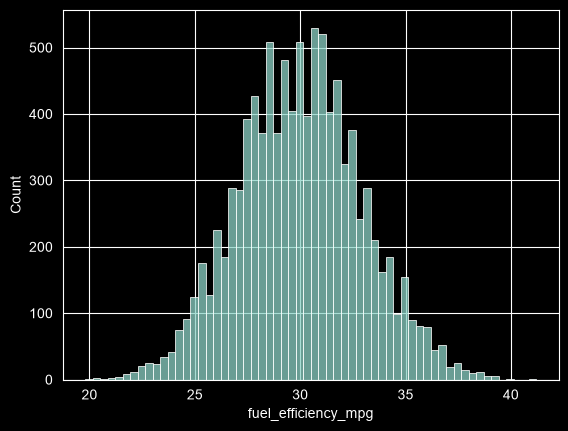

In [65]:
sns.histplot(df.fuel_efficiency_mpg)

Dataset information:

In [66]:
df[features].info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   engine_displacement  10000 non-null  int64  
 2   horsepower           9123 non-null   float64
 3   vehicle_weight       10000 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 312.6 KB


_________________________________________________________________________________________________________________


1.Missing values

In [67]:
df[features].isnull().sum()

model_year               0
engine_displacement      0
horsepower             877
vehicle_weight           0
dtype: int64

_________________________________________________________________________________________________________________


2.Median for horsepower

In [68]:
df["horsepower"].median()

np.float64(254.0)

_________________________________________________________________________________________________________________


3. Filling NAs

In [69]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

#____________________________________________________________________________________________________
#        Analyzing the distribution os null values in the training,validation, and test sets
#____________________________________________________________________________________________________
nulls_train = df_train[features].isnull().sum()[df_train[features].isnull().sum() > 0]
nulls_val = df_val[features].isnull().sum()[df_val[features].isnull().sum() > 0]
nulls_test = df_test[features].isnull().sum()[df_test[features].isnull().sum() > 0]

print(f'nulls_train: {nulls_train}')
print(f'nulls_val: {nulls_val}')
print(f'nulls_test: {nulls_test}')

#____________________________________________________________________________________________________
#                                              Observation:
#____________________________________________________________________________________________________
#Checking whether values are distributed across the training, validation, and test sets in the same proportion as the data (60/20/20). This is crucial to ensure the model learns fairly and reliably, without biases across the different stages.

nulls_train: horsepower    538
dtype: int64
nulls_val: horsepower    176
dtype: int64
nulls_test: horsepower    163
dtype: int64


In [70]:
#____________________________________________________________________________________________________
#imports
#____________________________________________________________________________________________________
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error


#_____________________________________________________________________________________________________
#                                Train | Validation | Test
#_____________________________________________________________________________________________________
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]


#_____________________________________________________________________________________________________
#                                          reset index
#_____________________________________________________________________________________________________
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


#_____________________________________________________________________________________________________
#Pad with zeros
#_____________________________________________________________________________________________________
train_with_zeros = df_train['horsepower'].fillna(0)
val_with_zeros = df_val['horsepower'].fillna(0)
test_with_zeros = df_test['horsepower'].fillna(0)


#_____________________________________________________________________________________________________
#                                     Fill with the average
#_____________________________________________________________________________________________________
mean_train = df_train['horsepower'].mean()

train_with_mean = df_train['horsepower'].fillna(mean_train)
val_with_mean = df_val['horsepower'].fillna(mean_train)
test_with_mean = df_test['horsepower'].fillna(mean_train)


#_____________________________________________________________________________________________________
#                          Adding the null features filled with zeros
#_____________________________________________________________________________________________________
X_train_zero = df_train.copy()
X_train_zero['horsepower'] = train_with_zeros
X_tr_zero = X_train_zero[features]


X_val_zero = df_val.copy()
X_val_zero['horsepower'] = val_with_zeros
X_va_zero = X_val_zero[features]


X_test_zero = df_test.copy()
X_test_zero['horsepower'] = test_with_zeros
X_tes_zero = X_test_zero[features]


#_____________________________________________________________________________________________________
#                          Adding the null features filled with mean
#_____________________________________________________________________________________________________
X_train_mean = df_train.copy()
X_train_mean['horsepower'] = train_with_mean
X_tr_mean = X_train_mean[features]


X_val_mean = df_val.copy()
X_val_mean['horsepower'] = val_with_mean
X_va_mean = X_val_mean[features]


X_test_mean = df_test.copy()
X_test_mean['horsepower'] = test_with_mean
X_tes_mean = X_test_mean[features]


#_____________________________________________________________________________________________________
#                                        Target
#_____________________________________________________________________________________________________
y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

#_____________________________________________________________________________________________________
#                                      Create model zero
#_____________________________________________________________________________________________________
model_zero = LinearRegression()
model_zero.fit(X_tr_zero, y_train)


#_____________________________________________________________________________________________________
#                                       Pred model zero
#_____________________________________________________________________________________________________
y_pred_val_zero = model_zero.predict(X_va_zero)

y_pred_test_zero = model_zero.predict(X_tes_zero)


#_____________________________________________________________________________________________________
#                                       Create model mean
#_____________________________________________________________________________________________________
model_mean = LinearRegression()
model_mean.fit(X_tr_mean, y_train)


#_____________________________________________________________________________________________________
#                                      Pred model mean
#_____________________________________________________________________________________________________
y_pred_val_mean = model_mean.predict(X_va_mean)

y_pred_test_mean = model_mean.predict(X_tes_mean)


#_____________________________________________________________________________________________________
#                                              RMSE
#_____________________________________________________________________________________________________
rmse_val_zero = root_mean_squared_error(y_val, y_pred_val_zero)

rmse_test_zero = root_mean_squared_error(y_test, y_pred_test_zero)

rmse_val_mean = root_mean_squared_error(y_val, y_pred_val_mean)

rmse_test_mean = root_mean_squared_error(y_test, y_pred_test_mean)


#_____________________________________________________________________________________________________
#                                              Result
#_____________________________________________________________________________________________________
print(f'rmse_val_zero: {rmse_val_zero}')
print(f'rmse_test_zero: {rmse_test_zero}')
print(f'rmse_val_mean: {rmse_val_mean}')
print(f'rmse_test_mean: {rmse_test_mean}')

rmse_val_zero: 2.205293194751566
rmse_test_zero: 2.2378460565965113
rmse_val_mean: 2.2018174845685903
rmse_test_mean: 2.234068477339271


4. Best regularization

In [71]:
from sklearn.linear_model import Ridge

r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in r_values:
    model_ridge = Ridge(alpha=r)
    model_ridge.fit(X_tr_zero, y_train)

    y_pred_val_ridge = model_ridge.predict(X_va_zero)
    rmse_val_ridge = root_mean_squared_error(y_val, y_pred_val_ridge)

    print(f'r={r:<6} rmse_val={round(rmse_val_ridge, 4)}')

r=0      rmse_val=2.2053
r=0.01   rmse_val=2.2053
r=0.1    rmse_val=2.2053
r=1      rmse_val=2.2053
r=5      rmse_val=2.2053
r=10     rmse_val=2.2053
r=100    rmse_val=2.2053


5. RMSE standard deviation

In [72]:
rmse_scores = []


for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    #__________________________________
    #      Train | Validation
    #__________________________________
    n = len(df)
    n_val = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    #___________________________________________
    #               reset index
    #___________________________________________
    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)

    #___________________________________________
    #              Pad with zeros
    #___________________________________________
    train_with_zeros = df_train['horsepower'].fillna(0)
    val_with_zeros = df_val['horsepower'].fillna(0)

    #___________________________________________
    #adding the null features filled with zeros
    #___________________________________________
    X_train_zero = df_train.copy()
    X_train_zero['horsepower'] = train_with_zeros
    X_tr_zero = X_train_zero[features]

    X_val_zero = df_val.copy()
    X_val_zero['horsepower'] = val_with_zeros
    X_va_zero = X_val_zero[features]

    #___________________________________________
    #                 Target
    #___________________________________________
    y_train = df_train['fuel_efficiency_mpg']
    y_val = df_val['fuel_efficiency_mpg']

    #___________________________________________
    #              Create model
    #___________________________________________
    model_zero = LinearRegression()
    model_zero.fit(X_tr_zero, y_train)

    #___________________________________________
    #                Predict
    #___________________________________________
    y_pred_val_zero = model_zero.predict(X_va_zero)

    #___________________________________________
    #                  rmse
    #___________________________________________
    rmse_val = root_mean_squared_error(y_val, y_pred_val_zero)
    rmse_scores.append(rmse_val)

#___________________________________________
#                   std
#___________________________________________
std = round(np.std(rmse_scores), 3)
print(std)

0.029


6. Evaluation on test

In [73]:
#_____________________________________________________________________________________________________
#                                  Train | Validation | Test
#_____________________________________________________________________________________________________
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]


#_____________________________________________________________________________________________________
#                        Combining training and validation data and resetting
#_____________________________________________________________________________________________________
df_new_train = pd.concat([df_train,df_val]).reset_index(drop=True)
df_test.reset_index(drop=True)

#_____________________________________________________________________________________________________
#                                   filling the values with zeros
#_____________________________________________________________________________________________________
train_zero = df_new_train['horsepower'].fillna(0)
test_zero = df_test['horsepower'].fillna(0)


#_____________________________________________________________________________________________________
#                             Adding the null features filled with zeros
#_____________________________________________________________________________________________________
X_t_new_zero = df_new_train.copy()
X_t_new_zero['horsepower'] = train_zero
X_tra_new_zero = X_t_new_zero[features]

X_test_zero = df_test.copy()
X_test_zero['horsepower'] = test_zero
X_tes_zero = X_test_zero[features]


#_____________________________________________________________________________________________________
#                                             Target
#_____________________________________________________________________________________________________
y_train = df_new_train['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']


#_____________________________________________________________________________________________________
#                                          Create model
#_____________________________________________________________________________________________________
# model_new = LinearRegression()
# model_new.fit(X_train_new_encoded, y_train)


#_____________________________________________________________________________________________________
#                                          Regularization
#_____________________________________________________________________________________________________
r = 0.001

model_new_ridge = Ridge(alpha=r)
model_new_ridge.fit(X_tra_new_zero, y_train)


#_____________________________________________________________________________________________________
#                                             Predict
#_____________________________________________________________________________________________________
y_pred = model_new_ridge.predict(X_tes_zero)


#_____________________________________________________________________________________________________
#                                              rmse
#_____________________________________________________________________________________________________
rmse_test = root_mean_squared_error(y_test, y_pred)
print(rmse_test)

2.2357747028137935
